In [1]:
import sys
from pathlib import Path
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import ModelConfig, DEFAULT_CONFIG, BATCH_SIZE, NUM_WORKERS, LEARNING_RATE, MAX_EPOCHS, WEIGHT_DECAY, RANDOM_SEEDS, XLSR_FEATURE_DIM, PROJECT_ROOT
from model import ADModel, create_model, SSLModel
from dataset import create_dataloaders

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: dlopen(/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <3F789787-FE38-3CE7-8599-064BDD0416EE> /opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/image.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/lib/libtorch_cpu.dylib
  warn(f"Failed to load image Python extension: {e}")


In [2]:
DATASET_NAME = "ADReSS-M"

In [3]:
# PROJECT_ROOT is now imported from config
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-val.csv"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/raw/{DATASET_NAME}_merged"
XLSR_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_xlsr_features"
TRAIN_RATIO = 0.8
FEATURE_DIR_NAME = f"{DATASET_NAME}_xlsr_features"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"{DATASET_NAME}_xlsr_multi_seed"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_COLOR = '#2E86AB'
VAL_COLOR = '#A23B72'

In [4]:
MAX_EPOCHS = MAX_EPOCHS
LEARNING_RATE = LEARNING_RATE
BATCH_SIZE = BATCH_SIZE
WEIGHT_DECAY = WEIGHT_DECAY
NUM_WORKERS = NUM_WORKERS
RANDOM_SEEDS = RANDOM_SEEDS

In [5]:
if torch.cuda.is_available():
      device = torch.device('cuda')
      accelerator = 'gpu'
elif torch.backends.mps.is_available():
      device = torch.device('mps')
      accelerator = 'mps'
else:
      device = torch.device('cpu')
      accelerator = 'cpu'
print(f"Using {device}")

Using mps


## Step 1: Create Train/Val Split for Address Dataset


In [6]:
from data_split import create_train_val_split

TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir = RAW_AUDIO_DIR,
    train_csv_path = TRAIN_CSV,
    val_csv_path = VAL_CSV,
    feature_dir_name = FEATURE_DIR_NAME,
    train_ratio=TRAIN_RATIO,
    random_seed = 42,
    dataset_name = DATASET_NAME
)

============= ADReSS-M Train/Val Split Complete! =============
Training set: 189 samples (Control: 92, Dementia: 97)
Validation set: 48 samples (Control: 23, Dementia: 25)

Training CSV path: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/ADReSS-M-xlsr-train.csv
Validation CSV path: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/ADReSS-M-xlsr-val.csv


## Step 2: Extract XLSR Features


In [7]:
# Extract XLSR features using single-csv function
from extract_XLSR_feature import extract_features_from_csv

ssl_model = SSLModel(device, freeze_xlsr=True)

extract_features_from_csv(
    csv_path=TRAIN_CSV,
    split_name="Train Set",
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)

extract_features_from_csv(
    csv_path=VAL_CSV,
    split_name="Val Set",
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)


XLSR:Using original XLSR model


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



============= Extracting XLSR features for Train Set =============
189 Audio Files


Extracting Train Set: 100%|██████████| 189/189 [00:00<00:00, 11610.91it/s]


Successfully extracted: 0
Already exists (skipped): 189
Errors: 0
Total: 189

============= Extracting XLSR features for Val Set =============
48 Audio Files


Extracting Val Set: 100%|██████████| 48/48 [00:00<00:00, 16400.02it/s]

Successfully extracted: 0
Already exists (skipped): 48
Errors: 0
Total: 48


(0, 48, 48)

## Step 4: Create Data Loaders


In [8]:
# Use XLSR features data loader (pre-extracted features)
train_loader, val_loader = create_dataloaders(
    TRAIN_CSV, VAL_CSV, 
    BATCH_SIZE, NUM_WORKERS,
    xlsr=True
)

all_results = {'seeds': [], 'val_accs': [], 'val_losses': []}

============= Creating training set (XLSR features) =============
✅ Loading completed: 189 samples
   Control: 92, Dementia: 97

============= Creating validation set (XLSR features) =============
✅ Loading completed: 48 samples
   Control: 23, Dementia: 25



## Step 5: Define Training Function and Model


In [9]:
from visualization import plot_training_curves

class MetricsCallback(pl.Callback):
    def __init__(self):
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epochs = []
    
    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get('train_loss', 0).item())
        self.train_acc.append(trainer.callback_metrics.get('train_acc', 0).item())
    
    def on_validation_end(self, trainer, pl_module):
        if not trainer.sanity_checking:
            self.epochs.append(trainer.current_epoch)
            self.val_loss.append(trainer.callback_metrics.get('val_loss', 0).item())
            self.val_acc.append(trainer.callback_metrics.get('val_acc', 0).item())

class ADClassifierXLSR(pl.LightningModule):
    def __init__(self):
        super().__init__()
        # Use original ADModel, but configure dim_input=XLSR_FEATURE_DIM (XLSR feature dimension)
        xlsr_config = ModelConfig(dim_input=XLSR_FEATURE_DIM, dim_hidden=DEFAULT_CONFIG.dim_hidden, dropout=DEFAULT_CONFIG.dropout)
        self.model = ADModel(xlsr_config)
        self.save_hyperparameters()
    def forward(self, x):
        return self.model(x)
    def training_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def validation_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def train_and_plot(seed, output_dir):
    """Train single seed and visualize"""
    pl.seed_everything(seed)
    seed_dir = output_dir / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)  # 自动创建不存在的父目录
    
    model = ADClassifierXLSR()
    metrics_cb = MetricsCallback()
    callbacks = [
        ModelCheckpoint(dirpath=seed_dir, filename='best', monitor='val_acc', mode='max', save_top_k=1),
        EarlyStopping(monitor='val_acc', patience=10, mode='max'),
        metrics_cb
    ]
     
    trainer_kwargs = {'max_epochs': MAX_EPOCHS, 'callbacks': callbacks, 'accelerator': accelerator,
                     'enable_progress_bar': True, 'enable_model_summary': False}
    if accelerator == 'gpu':
        trainer_kwargs['devices'] = 1
    trainer = pl.Trainer(**trainer_kwargs)
    
    trainer.fit(model, train_loader, val_loader)

    # Plot training curves
    plot_training_curves(
        epochs=metrics_cb.epochs,
        train_loss=metrics_cb.train_loss,
        val_loss=metrics_cb.val_loss,
        train_acc=metrics_cb.train_acc,
        val_acc=metrics_cb.val_acc,
        train_color=TRAIN_COLOR,
        val_color=VAL_COLOR,
        title_prefix=f'Seed {seed}'
    )

    best_val_acc_val = max(metrics_cb.val_acc)
    best_val_loss = min(metrics_cb.val_loss)
    print(f" Seed {seed} : Val Acc = {best_val_acc_val*100:.2f}%, Val Loss = {best_val_loss:.4f}")
    
    return seed, best_val_acc_val, best_val_loss


### 1st Random Seed = 21


Seed set to 21
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSS-M_xlsr_multi_seed/seed_21 exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 14: 100%|██████████| 6/6 [00:00<00:00, 23.50it/s, v_num=741, train_loss_step=0.290, train_acc_step=0.828, val_loss=0.914, val_acc=0.562, train_loss_epoch=0.291, train_acc_epoch=0.878] 


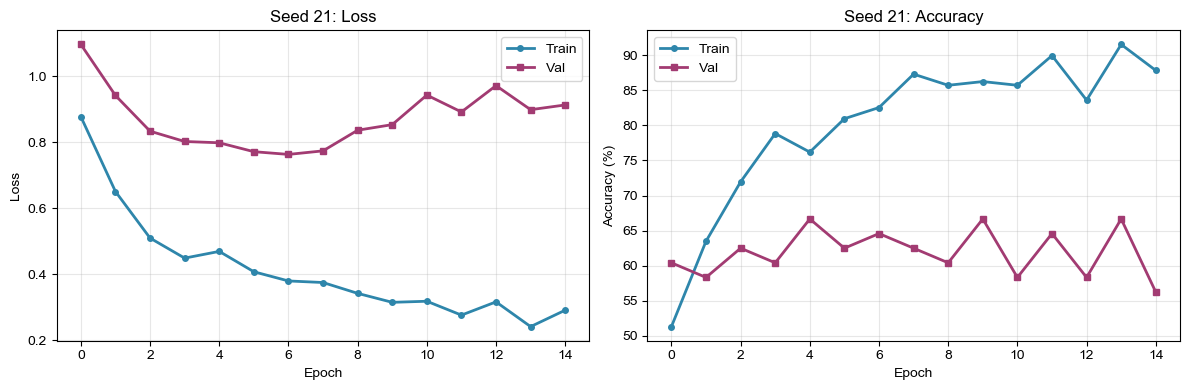

 Seed 21 : Val Acc = 66.67%, Val Loss = 0.7636


In [10]:
# Train Seed 21
seed, val_acc, val_loss = train_and_plot(21, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 2nd Random Seed = 42


Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSS-M_xlsr_multi_seed/seed_42 exists and is not empty.


Epoch 15: 100%|██████████| 6/6 [00:00<00:00, 118.05it/s, v_num=743, train_loss_step=0.356, train_acc_step=0.793, val_loss=1.160, val_acc=0.562, train_loss_epoch=0.233, train_acc_epoch=0.915]


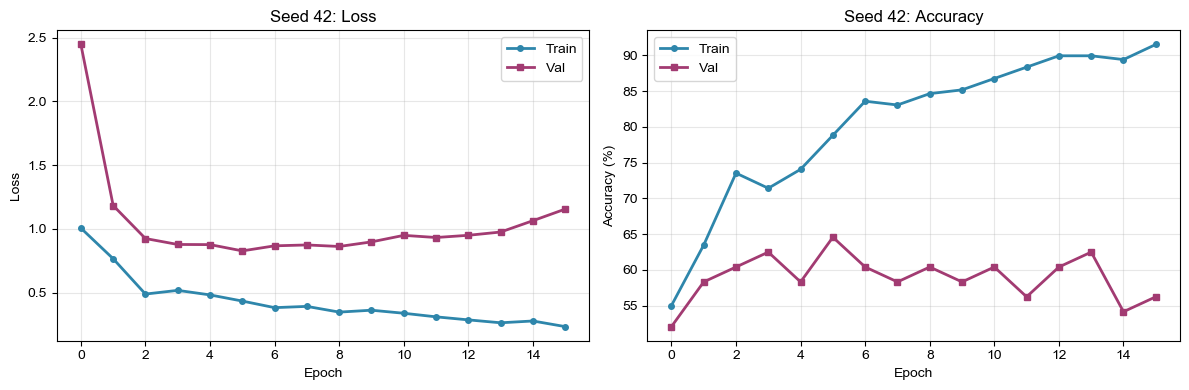

 Seed 42 : Val Acc = 64.58%, Val Loss = 0.8273


In [11]:
# Train Seed 42
seed, val_acc, val_loss = train_and_plot(42, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 3rd Random Seed = 84


Seed set to 84
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSS-M_xlsr_multi_seed/seed_84 exists and is not empty.


Epoch 13: 100%|██████████| 6/6 [00:00<00:00, 105.93it/s, v_num=745, train_loss_step=0.492, train_acc_step=0.724, val_loss=1.110, val_acc=0.521, train_loss_epoch=0.336, train_acc_epoch=0.868]


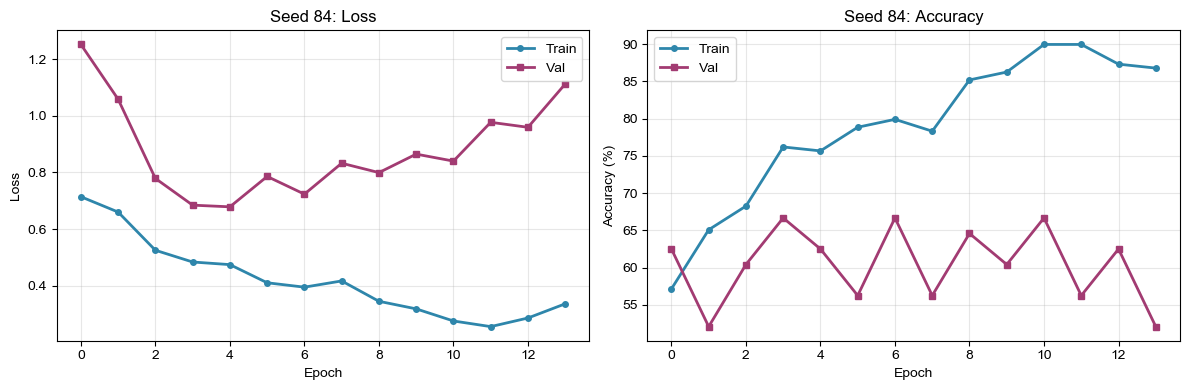

 Seed 84 : Val Acc = 66.67%, Val Loss = 0.6786


In [12]:
# Train Seed 84
seed, val_acc, val_loss = train_and_plot(84, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 4th Random Seed = 168


Seed set to 168
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSS-M_xlsr_multi_seed/seed_168 exists and is not empty.


Epoch 14: 100%|██████████| 6/6 [00:00<00:00, 106.70it/s, v_num=747, train_loss_step=0.494, train_acc_step=0.759, val_loss=0.972, val_acc=0.500, train_loss_epoch=0.336, train_acc_epoch=0.857]


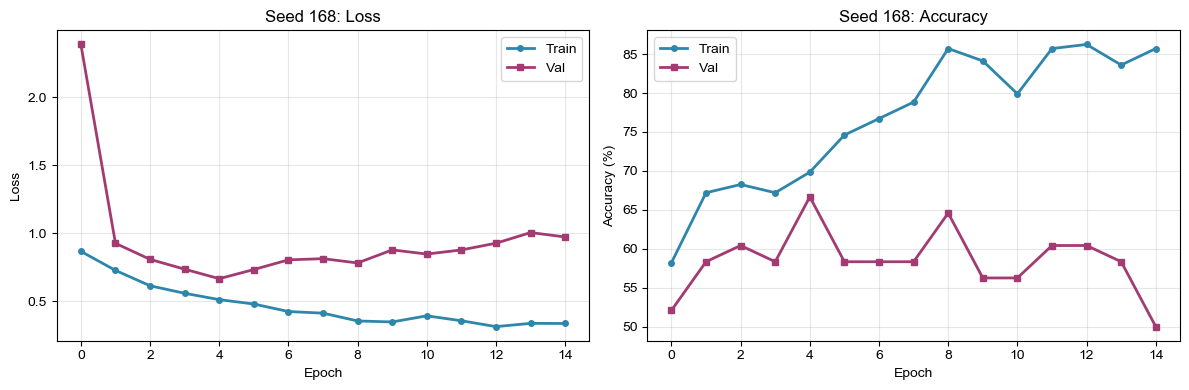

 Seed 168 : Val Acc = 66.67%, Val Loss = 0.6653


In [13]:
# Train Seed 168
seed, val_acc, val_loss = train_and_plot(168, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 5th Random Seed = 336


Seed set to 336
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSS-M_xlsr_multi_seed/seed_336 exists and is not empty.


Epoch 18: 100%|██████████| 6/6 [00:00<00:00, 107.23it/s, v_num=749, train_loss_step=0.137, train_acc_step=0.966, val_loss=1.120, val_acc=0.542, train_loss_epoch=0.192, train_acc_epoch=0.931]


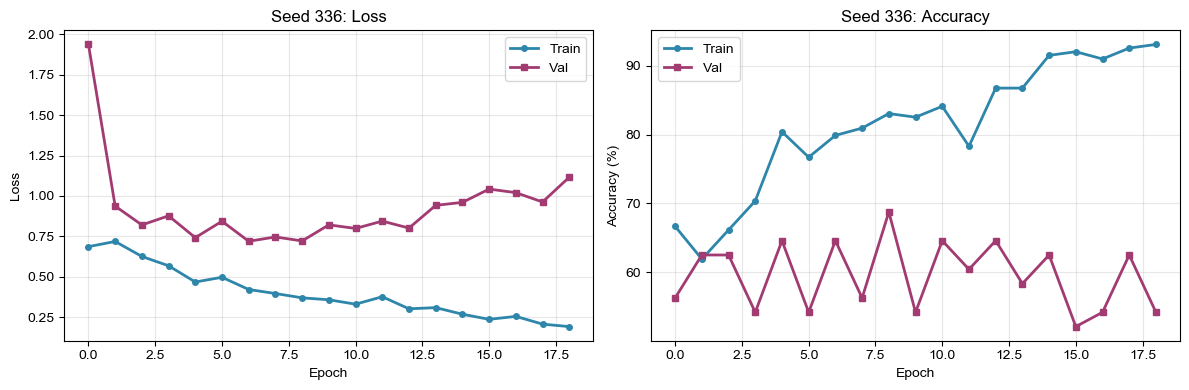

 Seed 336 : Val Acc = 68.75%, Val Loss = 0.7198


In [14]:
# Train Seed 336
seed, val_acc, val_loss = train_and_plot(336, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


In [15]:
# Compare all models
import numpy as np

seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']

# Calculate statistics
mean_acc = np.mean(val_accs)
mean_loss = np.mean(val_losses)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f}")
print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"  Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}")



Mean Validation Accuracy: 66.67%
Mean Validation Loss: 0.7309

Detailed Results:
  Seed 21: Acc=66.67%, Loss=0.7636
  Seed 42: Acc=64.58%, Loss=0.8273
  Seed 84: Acc=66.67%, Loss=0.6786
  Seed 168: Acc=66.67%, Loss=0.6653
  Seed 336: Acc=68.75%, Loss=0.7198
